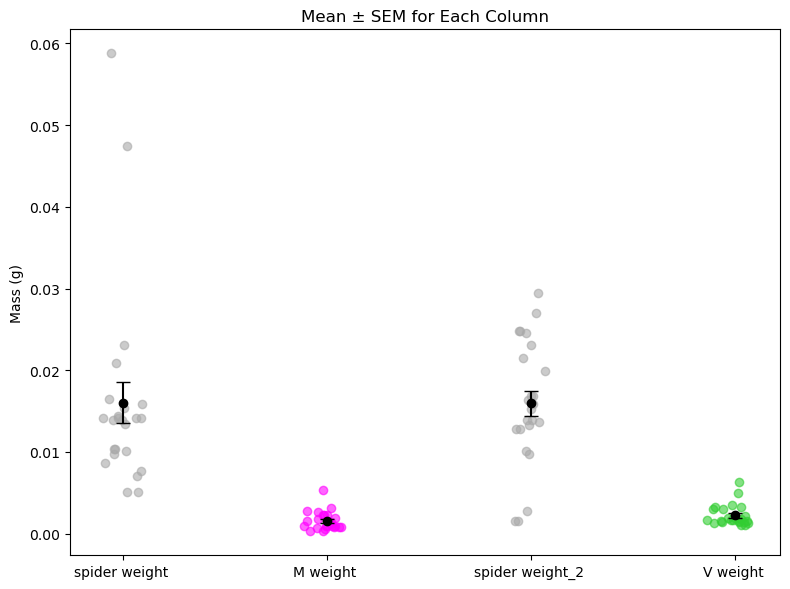

Mann–Whitney U statistic = 574.000, p-value = 0.0000


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Jun  4 10:54:32 2025

@author: hsinyihung
"""

import os, glob
import imageio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

control_name = 'D.Melano_weight_webvibration.csv'

directory = 'data/'
df = pd.read_csv(directory + control_name, header=0)

# Calculate mean and SEM
means = df.mean()
sems = df.sem()  # pandas has a built-in method for SEM!

# Create scatter plot with error bars (SEM)
plt.figure(figsize=(8, 6))
x = np.arange(len(df.columns))
plt.errorbar(x, means, yerr=sems, fmt='o', capsize=5, linestyle='None', color='black', ecolor='black')

# Plot individual data points with jitter
for i, col in enumerate(df.columns):
    jitter = np.random.normal(0, 0.05, size=len(df[col]))  # small horizontal jitter
    if col == 'V weight ':
        plt.scatter(np.full_like(df[col], x[i]) + jitter, df[col], alpha=0.6, label=f'{col} data' if i == 0 else "",
                    color='limegreen')
    elif col == 'M weight ':
        plt.scatter(np.full_like(df[col], x[i]) + jitter, df[col], alpha=0.6, label=f'{col} data' if i == 0 else "",
                    color='magenta')
    else:
        plt.scatter(np.full_like(df[col], x[i]) + jitter, df[col], alpha=0.6, label=f'{col} data' if i == 0 else "",
                    color='darkgrey')

# Customize plot
plt.xticks(x, df.columns)
plt.ylabel('Mass (g)')
plt.title('Mean ± SEM for Each Column')

plt.tight_layout()
plt.show()
from scipy.stats import mannwhitneyu

# Compare column 'A' and 'B'
stat, p = mannwhitneyu(df['spider weight '], df['M weight '], alternative='two-sided')

print(f'Mann–Whitney U statistic = {stat:.3f}, p-value = {p:.4f}')


Mann–Whitney U statistic = 405.500, p-value = 0.0158


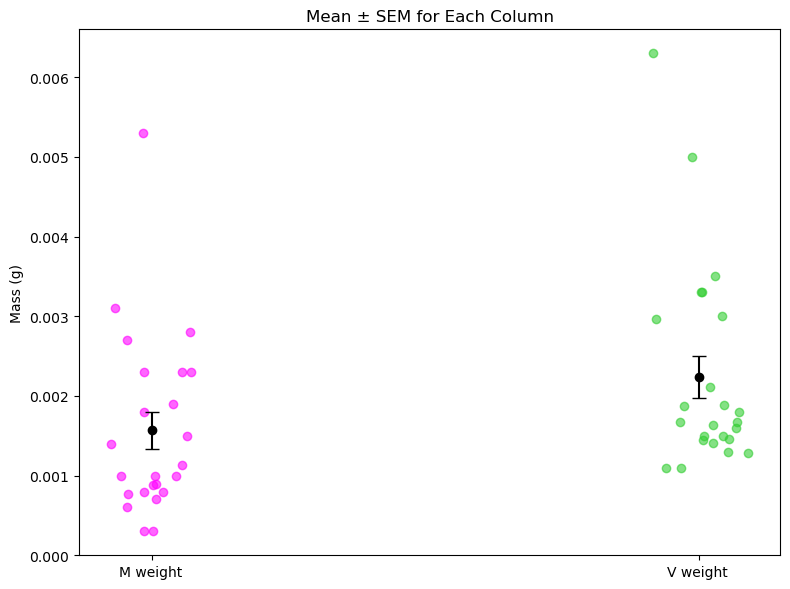

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Jun  4 10:54:32 2025

@author: hsinyihung
"""

import os, glob
import imageio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

control_name = 'D.Melano_weight_webvibration.csv'

directory = 'data/'
df = pd.read_csv(directory + control_name, header=0)
df = df.drop(columns=['spider weight ', 'spider weight_2 '])
# Calculate mean and SEM
means = df.mean()
sems = df.sem()  # pandas has a built-in method for SEM!

# Create scatter plot with error bars (SEM)
plt.figure(figsize=(8, 6))
x = np.arange(len(df.columns))
plt.errorbar(x, means, yerr=sems, fmt='o', capsize=5, linestyle='None', color='black', ecolor='black')

# Plot individual data points with jitter
for i, col in enumerate(df.columns):

    jitter = np.random.normal(0, 0.05, size=len(df[col]))  # small horizontal jitter
    if col == 'V weight ':
        plt.scatter(np.full_like(df[col], x[i]) + jitter, df[col], alpha=0.6, label=f'{col} data' if i == 0 else "",
                        color='limegreen')
    elif col == 'M weight ':
        plt.scatter(np.full_like(df[col], x[i]) + jitter, df[col], alpha=0.6, label=f'{col} data' if i == 0 else "",
                        color='magenta')
    else:
        plt.scatter(np.full_like(df[col], x[i]) + jitter, df[col], alpha=0.6, label=f'{col} data' if i == 0 else "",
                        color='darkgrey')
    
    # Customize plot
plt.xticks(x, df.columns)
plt.ylabel('Mass (g)')
plt.title('Mean ± SEM for Each Column')
plt.savefig('mass_prey.svg')
plt.tight_layout()

from scipy.stats import mannwhitneyu

# Compare column 'A' and 'B'
stat, p = mannwhitneyu(df['V weight '], df['M weight '], alternative='two-sided')

print(f'Mann–Whitney U statistic = {stat:.3f}, p-value = {p:.4f}')


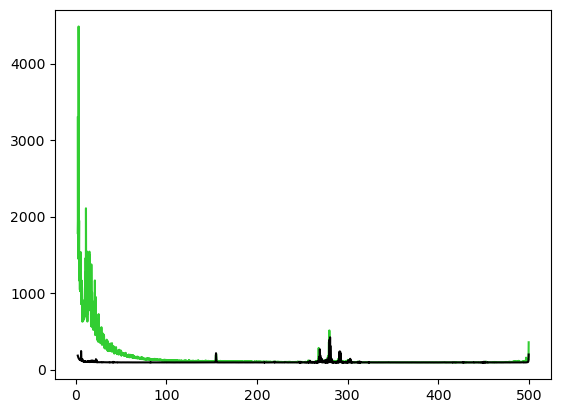

In [4]:
import os, matplotlib.pyplot as plt, scipy
import cv2
import skimage.draw, numpy as np
import pandas as pd



fft_name = '042425_prey2_C001H001S0001_fft.npz'
control_name = '042425_control_air2_C001H001S0001_fft.npz'
directory = 'data/'
fname = directory+fft_name

fft = np.load(fname)
fft_control = np.load(directory+control_name)



ff = fft['ff']
fft=fft['dataFFT']
fft_control = fft_control['dataFFT']
plt.figure()
plt.plot(ff[ff > 2], np.mean(fft, axis=0)[ff > 2], c='limegreen')
plt.plot(ff[ff > 2], np.mean(fft_control, axis=0)[ff > 2], c='black')
plt.show()



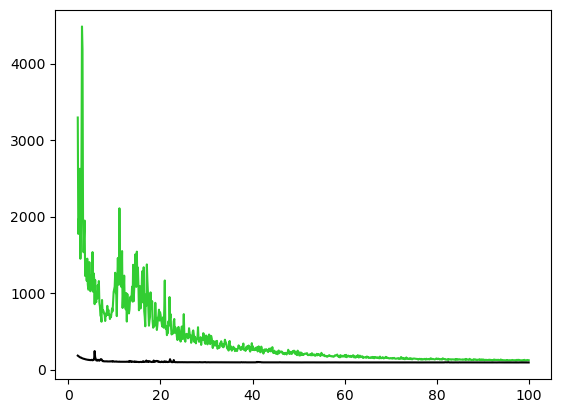

In [5]:

plt.figure()
plt.plot(ff[(ff > 2) & (ff < 100)], np.mean(fft, axis=0)[(ff > 2) & (ff < 100)], c='limegreen')
plt.plot(ff[(ff > 2) & (ff < 100)], np.mean(fft_control, axis=0)[(ff > 2) & (ff < 100)], c='black')
plt.show()



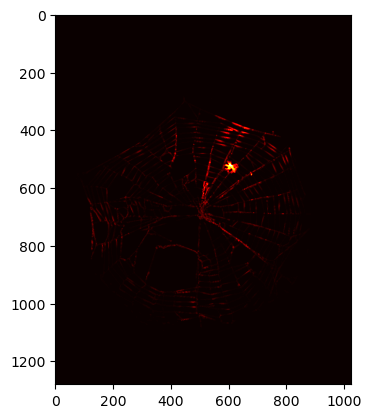

In [6]:
auc = np.load(directory+'042425_prey2_C001H001S0001_5-30hz_auc.npz')
auc=auc['AUC']
fig = plt.figure()
plt.imshow(auc[:,:,0], vmax =200000, cmap='hot')

<Figure size 640x480 with 0 Axes>

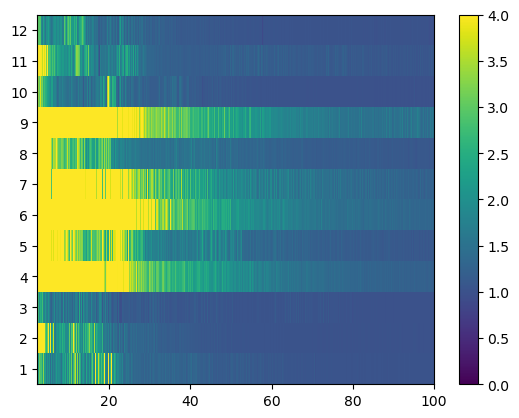

In [7]:
import os, glob
import imageio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

control_name = 'FFT_table_control_v.csv'
fft_name = 'FFT_table_prey_v.csv'
directory = 'data/'
fname = directory+fft_name

df_control = pd.read_csv(directory+control_name, index_col=[0])
df_fft = pd.read_csv(directory+fft_name, index_col=[0])



### 0-50 HZ

df_control = df_control.drop(columns=['fname'])
##drop f <2.5 Hz
df_control = df_control.drop(df_control.columns[0:20], axis =1)


df_fft = df_fft.drop(columns=['fname'])
df_fft = df_fft.drop(df_fft.columns[0:20], axis =1)


ff = np.array(df_fft.columns[0:len(df_fft.columns)], dtype = float)

index = np.array(range(0,len(df_fft)), dtype = float)
df2 = df_fft.div(df_control, axis=0)

plt.style.use('default')
plt.figure()
fig,ax = plt.subplots()
im = ax.pcolormesh(ff, index, df2, vmin = 0, vmax = 4)
fig.colorbar(im)
ax.set_yticks(np.arange(0,len(index)))
ax.set_yticklabels(np.arange(1,len(index)+1))
plt.show()

In [8]:
mean_prey_v = df2.mean(axis=0)
sem_prey_v = df2.sem(axis=0)

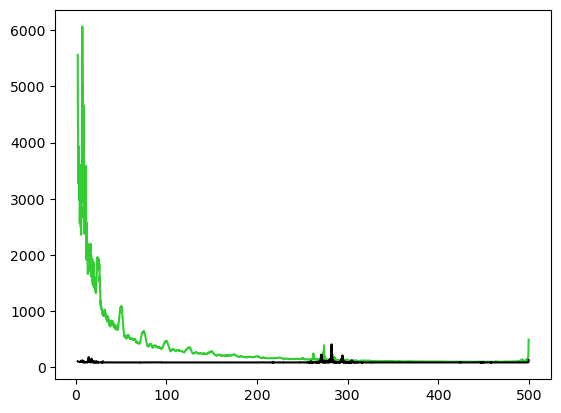

In [18]:

fft_name = '050925_spider_preyl1_C001H001S0001_nohand_fft.npz'
control_name = '050925_spider_control1_C001H001S0001_fft.npz'
directory = 'data/'
fname = directory+fft_name

fft = np.load(fname)
fft_control = np.load(directory+control_name)



ff = fft['ff']
fft=fft['dataFFT']
ff_control = fft_control['ff']
fft_control = fft_control['dataFFT']

plt.figure()
plt.plot(ff[ff > 2], np.mean(fft, axis=0)[ff > 2], c='limegreen')
plt.plot(ff_control[ff_control > 2], np.mean(fft_control, axis=0)[ff_control > 2], c='black')
plt.show()


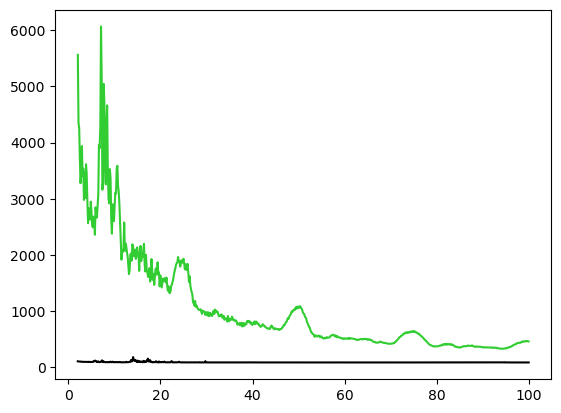

In [19]:

plt.figure()
plt.plot(ff[(ff > 2) & (ff < 100)], np.mean(fft, axis=0)[(ff > 2) & (ff < 100)], c='limegreen')
plt.plot(ff_control[(ff_control > 2) & (ff_control < 100)], np.mean(fft_control, axis=0)[(ff_control > 2) & (ff_control < 100)], c='black')
plt.show()

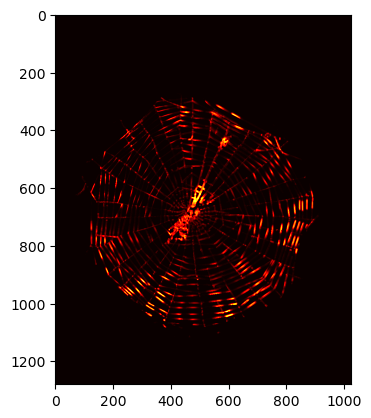

In [22]:
auc = np.load(directory+'050925_spider_preyl1_C001H001S0001_nohand_5-20hz_auc.npz')
auc=auc['AUC']
fig = plt.figure()
plt.imshow(auc[:,:,20], vmax = 175000, cmap='hot')

<Figure size 640x480 with 0 Axes>

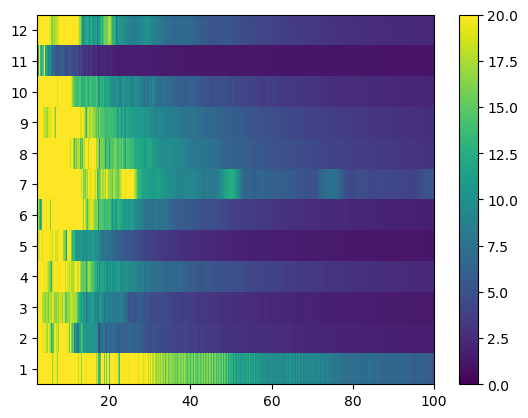

In [23]:
import os, glob
import imageio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

control_name = 'FFT_table_spider_control_v.csv'
fft_name = 'FFT_table_spider_prey_v.csv'
directory = 'data/'
fname = directory+fft_name

df_control = pd.read_csv(directory+control_name, index_col=[0])
df_fft = pd.read_csv(directory+fft_name, index_col=[0])



### 0-50 HZ

df_control = df_control.drop(columns=['fname'])
##drop f <2.5 Hz
df_control = df_control.drop(df_control.columns[0:20], axis =1)


df_fft = df_fft.drop(columns=['fname'])
df_fft = df_fft.drop(df_fft.columns[0:20], axis =1)


ff = np.array(df_fft.columns[0:len(df_fft.columns)], dtype = float)

index = np.array(range(0,len(df_fft)), dtype = float)
df2 = df_fft.div(df_control, axis=0)

plt.style.use('default')
plt.figure()
fig,ax = plt.subplots()
im = ax.pcolormesh(ff, index, df2, vmin = 0, vmax = 20)
fig.colorbar(im)
ax.set_yticks(np.arange(0,len(index)))
ax.set_yticklabels(np.arange(1,len(index)+1))
plt.show()

In [25]:
mean_spider_prey_v = df2.mean(axis=0)
sem_spider_prey_v = df2.sem(axis=0)


Dataset 1: mean=3.28, SEM=0.51, n=12
Dataset 2: mean=2.88, SEM=0.25, n=12
Welch's t-test: t=0.694, p=0.497


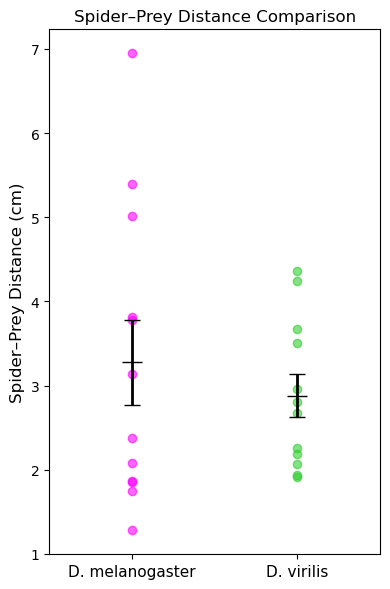

In [14]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ── 1. Load data ──────────────────────────────────────────────────────────────
df1 = pd.read_csv('data/Distance_table_spider_prey.csv')
df2 = pd.read_csv('data/Distance_table_spider_prey_v.csv')

col = 'Distance(cm)'
d1 = df1[col].dropna().values
d2 = df2[col].dropna().values

# ── 2. Statistics ─────────────────────────────────────────────────────────────
t, p = stats.ttest_ind(d1, d2, equal_var=False)  # Welch's t-test
print(f"Dataset 1: mean={np.mean(d1):.2f}, SEM={stats.sem(d1):.2f}, n={len(d1)}")
print(f"Dataset 2: mean={np.mean(d2):.2f}, SEM={stats.sem(d2):.2f}, n={len(d2)}")
print(f"Welch's t-test: t={t:.3f}, p={p:.3f}")

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 6))

# Scatter points
x1 = np.ones(len(d1)) * 1
x2 = np.ones(len(d2)) * 2
ax.scatter(x1, d1, alpha=0.6, color='magenta', zorder=3, label='D. melanogaster')
ax.scatter(x2, d2, alpha=0.6, color='limegreen',    zorder=3, label='D. virilis')

# Mean ± SEM bars  ← only change here
for x, d, color in zip([1, 2], [d1, d2], ['black', 'black']):
    ax.errorbar(x, np.mean(d), yerr=stats.sem(d),  # ← SEM instead of SD
                fmt='_', color=color, capsize=6, linewidth=2, markersize=15, zorder=4)

# Significance bracket

if p < 0.001:
    sig = '***'
elif p < 0.01:
    sig = '**'
elif p < 0.05:
    sig = '*'
else:
    sig = 'n.s.'


# Formatting
ax.set_xticks([1, 2])
ax.set_xticklabels(['D. melanogaster', 'D. virilis'], fontsize=11)
ax.set_ylabel('Spider–Prey Distance (cm)', fontsize=12)
ax.set_title('Spider–Prey Distance Comparison', fontsize=12)
ax.set_xlim(0.5, 2.5)


plt.tight_layout()
plt.savefig('distance_comparison.svg', dpi=300)
plt.show()